In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional, Literal
# Literal allows only specific element to be a part of function.

In [ ]:
class QuadraticState(TypedDict, total= False):
    a : int
    b : int
    c : int

    equation : str
    discriminent : float
    result : str

In [18]:
def show_equation(state : QuadraticState):
    equ = f'{state['a']}x2{state['b']}x{state['c']}'
    return {'equation' : equ}

In [19]:
def cal_discriminent(state : QuadraticState):
    discriminent = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminent' : discriminent}

In [20]:
def cal_real_roots(state : QuadraticState):
    root1 = (-state['b'] + state['discriminent']**0.5) / 2*state['a'] # **0.5 means sq-root.
    root2 = (-state['b'] - state['discriminent']**0.5) / 2*state['a']
    result = f'Real Roots are {root1} and {root2}'
    return {'result' : result}

In [21]:
def cal_repeated_root(state : QuadraticState):
    root = (-state['b']) / 2*state['a']
    result = f'Repeating Roots are {root}'
    return {'result' : result}

In [22]:
def cal_no_real_root(state : QuadraticState):
    result = f'No Real Roots'
    return {'result' : result}

In [23]:
def check_condition(state : QuadraticState) -> Literal['cal_real_roots', 'cal_repeated_root', 'cal_no_real_root']:
    if state['discriminent'] > 0:
        return 'cal_real_roots'
    elif state['discriminent'] == 0:
        return 'cal_repeated_root'
    else:
        return 'cal_no_real_root'

In [24]:
graph = StateGraph(QuadraticState)

graph.add_node('show_equation', show_equation)
graph.add_node('cal_discriminent', cal_discriminent)
graph.add_node('cal_real_roots', cal_real_roots)
graph.add_node('cal_repeated_root', cal_repeated_root)
graph.add_node('cal_no_real_root', cal_no_real_root)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'cal_discriminent')

graph.add_conditional_edges('cal_discriminent', check_condition)
graph.add_edge('cal_real_roots', END)
graph.add_edge('cal_repeated_root', END)
graph.add_edge('cal_no_real_root', END)

workflow = graph.compile()

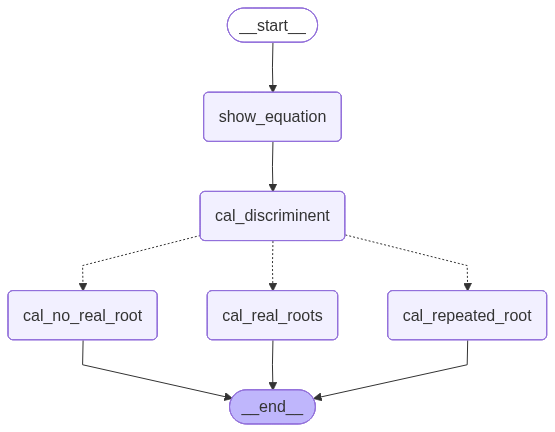

In [25]:
workflow

In [26]:
user_query = {
    'a' : 3,
    'b' : 5,
    'c' : 2
}

final_result = workflow.invoke(user_query)
print(final_result)

{'a': 3, 'b': 5, 'c': 2, 'equation': '3x25x2', 'discriminent': 1, 'result': 'Real Roots are -6.0 and -9.0'}
